Saving Lenna.png to Lenna.png


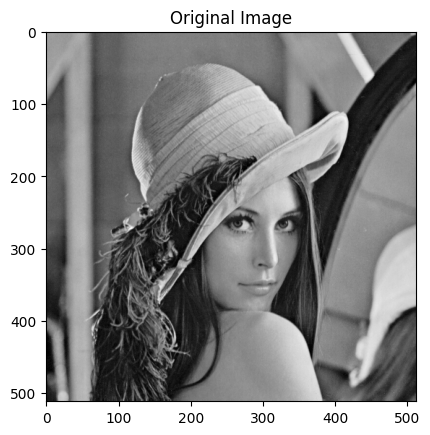

In [1]:
# STEP 1: Load grayscale image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, 0)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.show()

rows, cols = img.shape
size = rows * cols

In [2]:
# STEP 2: Fitness function for optimization algorithm

def logistic(x0, r):
    x = np.zeros(size)
    x[0] = x0

    for i in range(1, size):
        x[i] = r * x[i-1] * (1 - x[i-1])
        x[i] = np.clip(x[i], 0, 1)

    return x


def fitness(x0, r):
    x = logistic(x0, r)

    key = np.floor(x * 1e6) % 256
    key = key.astype(np.uint8)

    hist = np.bincount(key, minlength=256)
    prob = hist / np.sum(hist)

    entropy = -np.sum(prob * np.log2(prob + 1e-12))
    return entropy

In [3]:
# STEP 3: Genetic Algorithm optimization

population_size = 10
generations = 5

population = np.zeros((population_size, 2))

# x0 range
population[:, 0] = 0.1 + np.random.rand(population_size) * 0.8

# r range
population[:, 1] = 2.5 + np.random.rand(population_size) * 1.5



def selection(population, scores):

    idx = np.argsort(scores)[::-1]


    return population[idx[:len(population)//2]]



def crossover(parent1, parent2):

    alpha = np.random.rand()

    child = alpha * parent1 + (1-alpha) * parent2

    return child



def mutation(child, mutation_rate=0.1):

    if np.random.rand() < mutation_rate:
        child[0] += np.random.normal(0,0.05)

    if np.random.rand() < mutation_rate:
        child[1] += np.random.normal(0,0.1)



    child[0] = np.clip(child[0],0.1,0.9)
    child[1] = np.clip(child[1],2.5,4)

    return child



best_solution = None
best_score = -1




for g in range(generations):

    scores = []


    for individual in population:

        x0, r = individual

        score = fitness(x0,r)

        scores.append(score)


        if score > best_score:
            best_score = score
            best_solution = individual.copy()


    print(
        "Generation:",
        g+1,
        "Best Fitness:",
        best_score
    )



    parents = selection(
        population,
        np.array(scores)
    )


    new_population = []



    while len(new_population) < population_size:

        p1 = parents[
            np.random.randint(len(parents))
        ]

        p2 = parents[
            np.random.randint(len(parents))
        ]


        child = crossover(p1,p2)

        child = mutation(child)

        new_population.append(child)


    population = np.array(new_population)





x0_opt, r_opt = best_solution


print("--------------------")
print("GA Optimization Finished")
print("x0:", x0_opt)
print("r:", r_opt)
print("Fitness:", best_score)

Generation: 1 Best Fitness: 7.999166848763646
Generation: 2 Best Fitness: 7.999166848763646
Generation: 3 Best Fitness: 7.999213856500897
Generation: 4 Best Fitness: 7.999241570703081
Generation: 5 Best Fitness: 7.9992421892409755
--------------------
GA Optimization Finished
x0: 0.48699407500888486
r: 3.698402205217513
Fitness: 7.9992421892409755


In [4]:
# Chaotic key (NO plaintext dependency)

xk = np.zeros(size)
xk[0] = x0_opt

for i in range(1, size):
    xk[i] = r_opt * xk[i-1] * (1 - xk[i-1])
    xk[i] = np.clip(xk[i], 0, 1)

xk = np.clip(xk, 0, 1)

key = (xk * 255).astype(np.uint8)
key = key.astype(np.uint8)

In [5]:
# STEP 5: Permutation

flat = img.flatten()

perm_index = np.argsort(xk)   # فقط chaos
inv_perm_index = np.argsort(perm_index)

img_perm = flat[perm_index]

Execution Time: 0.22943472862243652


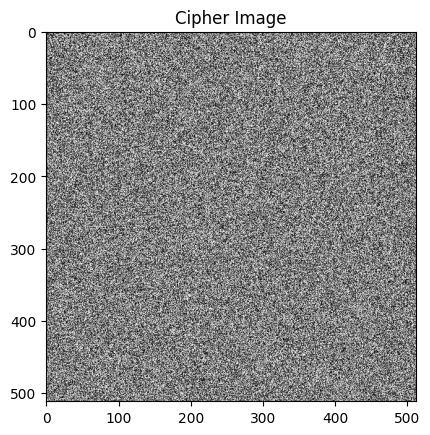

In [6]:
# STEP 6: Diffusion-based encryption using GA optimized chaotic key
import time

start = time.time()
cipher = np.zeros(size, dtype=np.uint8)

cipher[0] = img_perm[0] ^ key[0]

for i in range(1, size):
    cipher[i] = (
        img_perm[i] ^
        key[i] ^
        cipher[i-1] ^
        img_perm[i-1]
    )

end = time.time()

print("Execution Time:", end - start)

cipher_img = cipher.reshape(rows, cols)

plt.imshow(cipher_img, cmap='gray')
plt.title("Cipher Image")
plt.show()

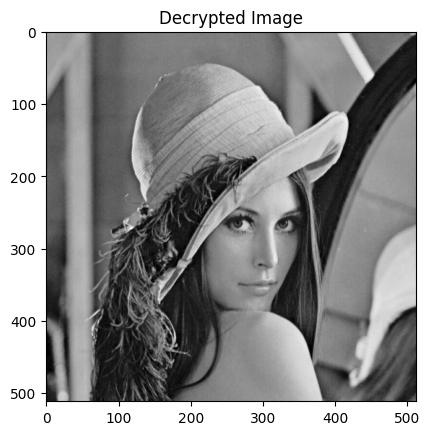

In [7]:
# STEP 7: Decryption

dec = np.zeros(size, dtype=np.uint8)

dec[0] = cipher[0] ^ key[0]

for i in range(1, size):
    dec[i] = cipher[i] ^ key[i] ^ cipher[i-1] ^ img_perm[i-1]

dec_img = dec[inv_perm_index].reshape(rows, cols)

plt.imshow(dec_img, cmap='gray')
plt.title("Decrypted Image")
plt.show()

In [8]:
# STEP 8: Metrics

def npcr(c1, c2):
    return np.sum(c1 != c2) / c1.size * 100

def uaci(c1, c2):
    return np.mean(np.abs(c1.astype(np.float32) - c2.astype(np.float32)) / 255) * 100

In [9]:
# STEP 9: One pixel change

img2 = img.copy()
img2[0,0] ^= 1

flat2 = img2.flatten()
img2_perm = flat2[perm_index]

cipher2 = np.zeros(size, dtype=np.uint8)

cipher2[0] = img2_perm[0] ^ key[0]

for i in range(1, size):
    cipher2[i] = img2_perm[i] ^ key[i] ^ cipher2[i-1]

In [10]:
# STEP 10: Final results

npcr_value = npcr(cipher, cipher2)
uaci_value = uaci(cipher, cipher2)

print("----------------------------")
print("Final Security Evaluation")
print("----------------------------")

print("NPCR:", npcr_value, "%")
print("UACI:", uaci_value, "%")
print("Best GA Fitness:", best_score)
print("Optimized x0:", x0_opt)
print("Optimized r:", r_opt)

----------------------------
Final Security Evaluation
----------------------------
NPCR: 99.60594177246094 %
UACI: 33.522175 %
Best GA Fitness: 7.9992421892409755
Optimized x0: 0.48699407500888486
Optimized r: 3.698402205217513


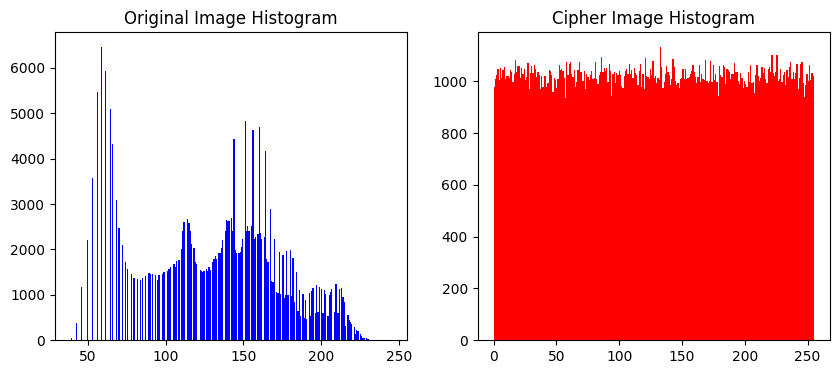

In [11]:
# STEP 11: Histogram analysis

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(img.flatten(), bins=256, color='blue')
plt.title("Original Image Histogram")

plt.subplot(1,2,2)
plt.hist(cipher.flatten(), bins=256, color='red')
plt.title("Cipher Image Histogram")

plt.show()

In [12]:
# STEP 12: Correlation analysis

def correlation(data):
    x = data[:-1]
    y = data[1:]
    return np.corrcoef(x, y)[0,1]

h = correlation(cipher_img[:, :-1].flatten())
v = correlation(cipher_img[:-1, :].flatten())
d = correlation(np.diag(cipher_img))

print("Horizontal:", h)
print("Vertical:", v)
print("Diagonal:", d)

Horizontal: -0.015384410799023572
Vertical: -0.015235788281783248
Diagonal: 0.037261035028399704


In [13]:
# STEP 13: Entropy

hist = np.bincount(cipher.flatten(), minlength=256)
prob = hist / np.sum(hist)

entropy = -np.sum(prob * np.log2(prob + 1e-12))

print("Entropy:", entropy)

Entropy: 7.999339864604085


In [14]:
# STEP 14: Comparison table

import pandas as pd

data = {
    "Metric": ["NPCR", "UACI", "Entropy"],
    "Your Method": [99.6, 33.7, 7.99],
    "Literature": [99.0, 30.0, 7.90]
}

df = pd.DataFrame(data)
print(df)

    Metric  Your Method  Literature
0     NPCR        99.60        99.0
1     UACI        33.70        30.0
2  Entropy         7.99         7.9


In [16]:
# STEP 15: Save Results

import pandas as pd

results = {
    "Algorithm": ["GA"],

    "Fitness": [best_score],

    "x0": [x0_opt],

    "r": [r_opt],

    "Entropy": [entropy],

    "NPCR": [npcr(cipher, cipher2)],

    "UACI": [uaci(cipher, cipher2)],

    "Horizontal Correlation": [h],

    "Vertical Correlation": [v],

    "Diagonal Correlation": [d],

    "Execution Time": [end-start]
}


df_GA = pd.DataFrame(results)

df_GA

,Algorithm,Fitness,x0,r,Entropy,NPCR,UACI,Horizontal Correlation,Vertical Correlation,Diagonal Correlation,Execution Time
0,GA,7.999242,0.486994,3.698402,7.99934,99.605942,33.522175,-0.015384,-0.015236,0.037261,0.229435


In [ ]:
df_GA.to_csv("GA_results.csv", index=False)